>>> 检测到 k=6.8668 矿石含 145 个点。


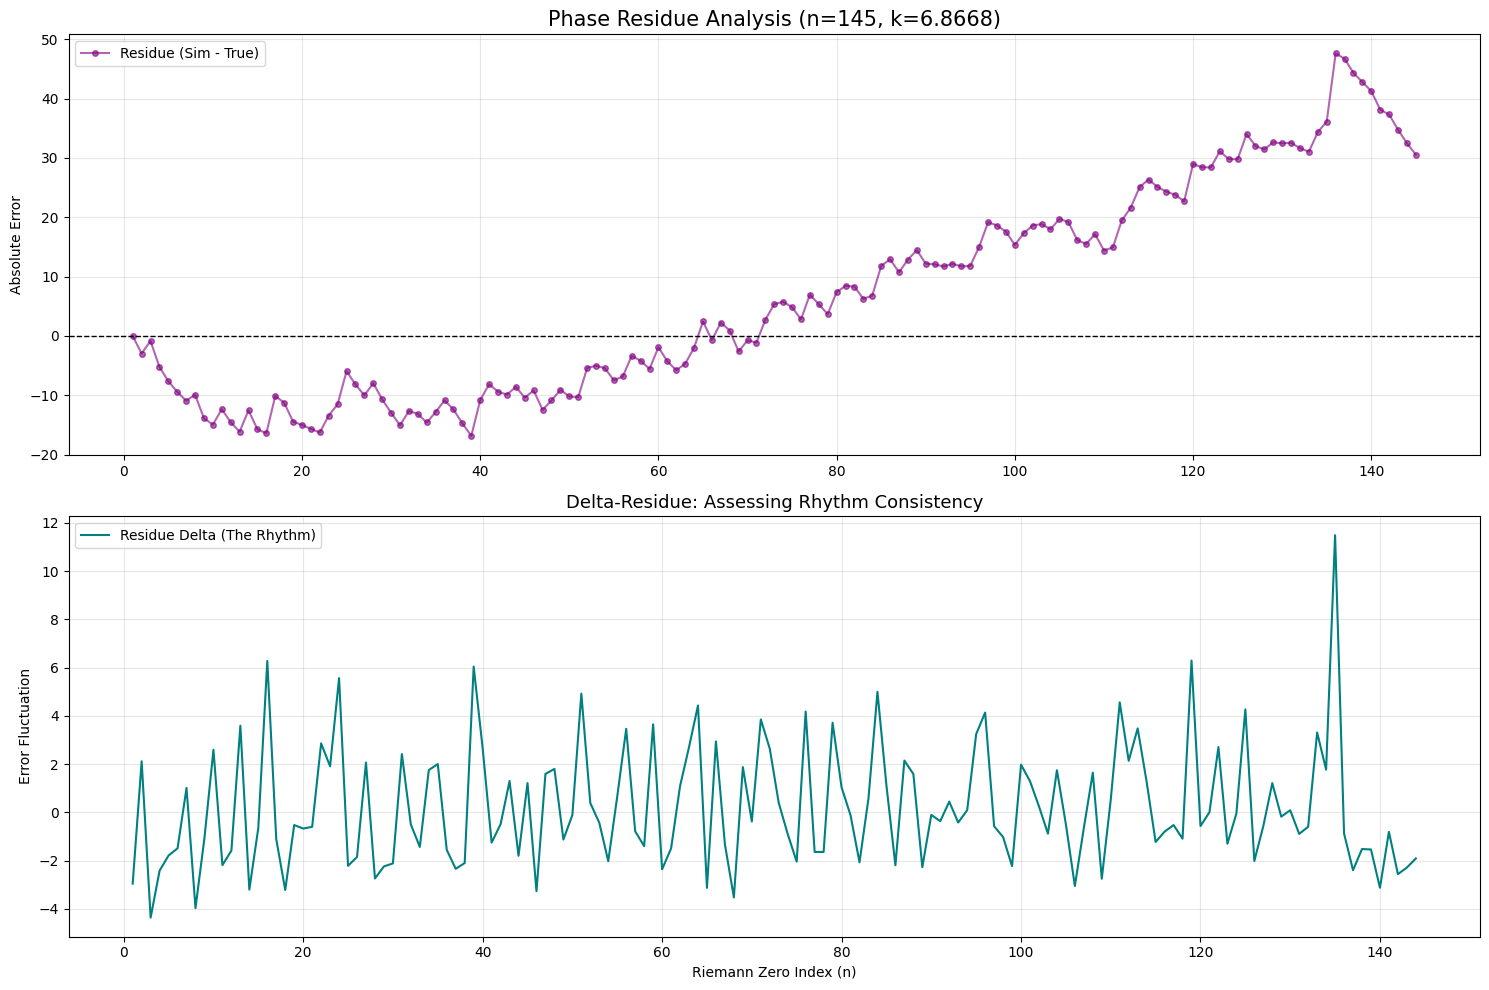

>>> 收割完成！已对齐前 145 个模式。


In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt

# --- 1. 160 个权威零点 ---
TRUE_GAMMAS_160 = np.array([
    14.1347, 21.0220, 25.0108, 30.4248, 32.9350, 37.5861, 40.9187, 43.3270, 48.0051, 49.7738,
    52.9703, 56.4462, 59.3470, 60.8317, 65.1125, 67.0798, 69.5464, 72.0671, 75.7046, 77.1448,
    79.3373, 82.9103, 84.7354, 87.4252, 88.8091, 92.4918, 94.6513, 95.8706, 98.8311, 101.3178,
    103.7255, 105.4466, 107.1686, 111.0295, 111.8746, 114.3202, 116.2266, 118.7907, 121.3701, 122.9468,
    124.2568, 127.5166, 129.5787, 131.0876, 133.4977, 134.7565, 138.1160, 139.7362, 141.1237, 143.1118,
    146.0009, 147.4227, 150.0535, 150.9252, 153.5650, 156.1129, 157.5975, 158.8499, 161.1889, 163.0307,
    165.5370, 167.1813, 169.0945, 171.2163, 172.2683, 175.7441, 177.3485, 178.6775, 182.2070, 184.8744,
    185.5987, 187.2289, 189.4161, 192.0266, 193.0769, 195.2653, 196.5764, 199.1571, 201.2647, 202.4935,
    204.6602, 205.3946, 207.9062, 210.3430, 211.6908, 213.3479, 216.4026, 217.4442, 219.0675, 221.4307,
    224.0070, 224.9833, 227.3457, 229.3374, 231.2501, 231.9872, 235.4702, 236.5242, 237.7698, 240.3510,
    242.8226, 244.1289, 246.3067, 248.4093, 250.8010, 251.5879, 254.8866, 255.7533, 257.3934, 260.4543,
    261.3936, 263.7816, 266.2418, 267.4452, 269.1551, 271.9039, 273.6166, 274.5624, 277.0607, 279.5101,
    281.3964, 282.4654, 284.8359, 287.4524, 288.7903, 290.3128, 293.0407, 294.3218, 296.5312, 298.5484,
    301.3236, 302.3101, 303.9577, 306.7554, 308.9167, 309.9501, 312.4433, 314.8450, 316.3687, 317.9101,
    321.0392, 321.8483, 324.4124, 326.7042, 328.6186, 329.5630, 332.6105, 333.6826, 335.5398, 338.4526,
    340.2307, 342.3682, 343.8329, 345.8569, 348.6672, 349.8824, 351.6550, 354.4093, 356.1219, 357.5143
])

def harvest_and_analyze():
    DATA_DIR = "riemann_200_pure"
    target_k = 6.8668 # 锁定的平台点
    target_file = os.path.join(DATA_DIR, f'pure_res_k_{target_k:.4f}_steps10t10.npy')
    
    if os.path.exists(target_file):
        phases = np.load(target_file)
        # 自动获取当前文件能提供的最大点数
        max_available = len(phases)
        print(f">>> 检测到 k={target_k} 矿石含 {max_available} 个点。")
        
        # 缩放校准
        scaling = TRUE_GAMMAS_160[0] / phases[0]
        sim_gammas = phases * scaling
        
        # 核心修复：对齐长度，防止 Broadcast 错误
        n_match = min(max_available, 160)
        residues = sim_gammas[:n_match] - TRUE_GAMMAS_160[:n_match]
        
        # 绘图
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
        
        # 1. 绝对残差分析
        ax1.plot(range(1, n_match + 1), residues, 'o-', color='purple', markersize=4, alpha=0.6, label='Residue (Sim - True)')
        ax1.axhline(0, color='black', lw=1, linestyle='--')
        ax1.set_title(f'Phase Residue Analysis (n={n_match}, k={target_k})', fontsize=15)
        ax1.set_ylabel('Absolute Error')
        ax1.grid(alpha=0.3)
        ax1.legend()
        
        # 2. 节奏波动分析
        ax2.plot(range(1, n_match), np.diff(residues), color='teal', label='Residue Delta (The Rhythm)')
        ax2.set_xlabel('Riemann Zero Index (n)')
        ax2.set_ylabel('Error Fluctuation')
        ax2.set_title('Delta-Residue: Assessing Rhythm Consistency', fontsize=13)
        ax2.grid(alpha=0.3)
        ax2.legend()
        
        plt.tight_layout()
        plt.savefig('Final_Harvest_Robust.png', dpi=300)
        plt.show()
        
        print(f">>> 收割完成！已对齐前 {n_match} 个模式。")
    else:
        print(f"找不到文件: {target_file}")

if __name__ == "__main__":
    harvest_and_analyze()